## Importação das bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carregamento dos dados

In [4]:
data_excel = pd.read_excel("ifood_mock_dataset.xlsx", sheet_name=None)
print(data_excel.keys())

dict_keys(['customers', 'merchants', 'riders', 'orders', 'reviews'])


### Tabela Customers

In [5]:
df_customers = data_excel["customers"]
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       500 non-null    int64         
 1   nome_completo     500 non-null    object        
 2   data_nascimento   481 non-null    datetime64[ns]
 3   cpf               500 non-null    object        
 4   cidade            500 non-null    object        
 5   estado            500 non-null    object        
 6   data_cadastro     500 non-null    datetime64[ns]
 7   opt_in_marketing  500 non-null    bool          
dtypes: bool(1), datetime64[ns](2), int64(1), object(4)
memory usage: 28.0+ KB


In [6]:
df_customers.head(5)

,customer_id,nome_completo,data_nascimento,cpf,cidade,estado,data_cadastro,opt_in_marketing
0,1,Cliente_1,1994-12-30,868.981.888-23,BH,MG,2023-10-28,True
1,2,Cliente_2,1991-02-14,897.535.324-32,Belo Horizonte,MG,2022-02-02,False
2,3,Cliente_3,1900-01-01,923.812.630-69,BH,MG,2022-04-06,False
3,4,Cliente_4,2000-12-26,151.670.355-25,RJ,RJ,2023-02-20,True
4,5,Cliente_5,2000-01-06,567.236.920-69,Sao Paulo,SP,2023-01-24,False


In [7]:
# Unificar o formato do CPF, removendo caracteres não numéricos
df_customers["cpf"] = df_customers["cpf"].astype(str).str.replace(r'\D', '', regex=True)

# Verificar se há CPF com tamanho inválido (diferente de 11 dígitos)
invalid_cpf = df_customers["cpf"].str.len() != 11
print(f"Quantidade de CPFs inválidos: {invalid_cpf.sum()}")

Quantidade de CPFs inválidos: 0


In [8]:
# Identificar se há duplicatas no CPF
print(df_customers["cpf"].duplicated().any()) # True -> há duplicatas
# Não pode haver duplicatas no CPF, pois é um identificador único de cada cliente. Portanto, duplicatas geralmente indicam erros de cadastro, tentativas de fraude ou atualizações de sistemas.

print(f"Quantidade de CPFs duplicados: {df_customers['cpf'].duplicated().sum()}")
print('--------------------------------\n')
# Dados "estranhos" são ouro para a equipe de Prevenção à Fraude. Em vez de apagar ou mascarar o dado, nós o mantemos, mas criamos uma nova coluna (uma flag) para sinalizar o problema.

df_customers["flag_cpf_duplicado"] = df_customers["cpf"].duplicated(keep=False)

# df_customers[df_customers["cpf"].duplicated(keep=False)]
df_customers["flag_cpf_duplicado"].head()

True
Quantidade de CPFs duplicados: 5
--------------------------------



0     True
1    False
2    False
3    False
4    False
Name: flag_cpf_duplicado, dtype: bool

Foram identificadas 5 duplicatas de CPF. As linhas em que constam essas duplicatas possuem os demais valores distintos. Como se trata de um dado único para cada cliente, essas duplicatas podem indicar tentativas de fraude ou erro de sistema. Apesar de 5 ocorrências representar apenas 1% da base de dados, não é recomendada a sua exclusão já que pode interferir na análise das outras tabelas (como a de pedidos, por exemplo). E como existe a possibilidade de ser tentativa de fraude, optamos por criar uma nova coluna `flag_cpf_duplicado` para que o time de Prevenção à Fraude possa investigar o problema.

Dessa análise dos CPFs duplicados foi possível perceber a existência de clientes cadastrados com menos de 18 anos. Entretanto, é permitido o cadastro a partir dos 16 anos de idade, conforme Termos de Uso do aplicativo. Ainda assim há clientes com idade menor que essa. Outro problema encontrado foram clientes nascidos em 01/01/1900, com mais de 100 anos. Esses dados precisam ser tratados.

In [9]:
# calcula os anos e compara se o aniversário já passou no ano do cadastro
years = df_customers["data_cadastro"].dt.year - df_customers["data_nascimento"].dt.year
had_birthday = (
    df_customers["data_cadastro"].dt.strftime("%m%d")
    >= df_customers["data_nascimento"].dt.strftime("%m%d")
)

df_customers["idade_cadastro"] = years - (~had_birthday).astype(int)

df_customers["idade_cadastro"].describe().round(2)

count    481.00
mean      21.24
std       16.70
min        5.00
25%       13.00
50%       20.00
75%       26.00
max      123.00
Name: idade_cadastro, dtype: float64

In [10]:
# Pelo método describe(), podemos ver que a idade mínima é 5 e a máxima é 123. É necessário ter ao menos 16 anos para se cadastrar.
age_condition = df_customers.loc[(df_customers["idade_cadastro"] > 100) | (df_customers["idade_cadastro"] < 16), ["nome_completo", "data_nascimento", "idade_cadastro"]]
age_condition = age_condition.sort_values(by="idade_cadastro", ascending=False)
print(f"Número de ocorrências: {len(age_condition)}")
age_condition.head(5)


Número de ocorrências: 180


,nome_completo,data_nascimento,idade_cadastro
196,Cliente_197,1900-01-01,123.0
75,Cliente_76,1900-01-01,123.0
335,Cliente_336,1900-01-01,123.0
2,Cliente_3,1900-01-01,122.0
367,Cliente_368,1900-01-01,122.0


In [11]:
# Os cadastros com mais de 100 possuem data de nascimento em 01/01/1900, o que provavelmente indica erro do usuário no momento do cadastro. Como são 180 datas de nascimento inválidas em uma base de 500, manteremos as linhas e alteraremos essas datas para um valor nulo, a fim de que não interfiram nas próximas análises.
df_customers.loc[age_condition.index, "data_nascimento"] = pd.NaT
df_customers.loc[age_condition.index, "idade_cadastro"] = np.nan
df_customers.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         500 non-null    int64         
 1   nome_completo       500 non-null    object        
 2   data_nascimento     301 non-null    datetime64[ns]
 3   cpf                 500 non-null    object        
 4   cidade              500 non-null    object        
 5   estado              500 non-null    object        
 6   data_cadastro       500 non-null    datetime64[ns]
 7   opt_in_marketing    500 non-null    bool          
 8   flag_cpf_duplicado  500 non-null    bool          
 9   idade_cadastro      301 non-null    float64       
dtypes: bool(2), datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 32.4+ KB


In [12]:
df_customers.loc[age_condition.index, "data_nascimento"] = pd.NaT

df_customers.loc[age_condition.index, ["nome_completo", "data_nascimento"]].head()

,nome_completo,data_nascimento
196,Cliente_197,NaT
75,Cliente_76,NaT
335,Cliente_336,NaT
2,Cliente_3,NaT
367,Cliente_368,NaT


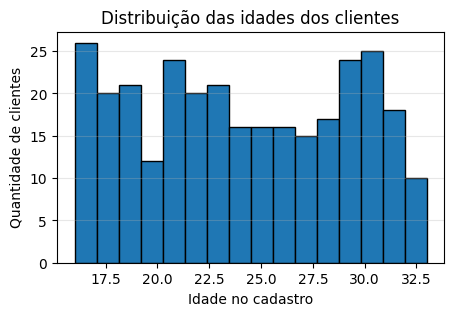

In [13]:
df_customers["idade_cadastro"].dropna().plot(
  kind="hist",
  bins=16,
  figsize=(5, 3),
  edgecolor="black"
)

plt.title("Distribuição das idades dos clientes")
plt.xlabel("Idade no cadastro")
plt.ylabel("Quantidade de clientes")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [14]:
# Tratamento da coluna cidade
df_customers["cidade"].unique()

array(['BH', 'Belo Horizonte', 'RJ', 'Sao Paulo', 'SP', 'São Paulo',
       'Rio de Janeiro', 'S. Paulo'], dtype=object)

In [15]:
# Dicionário de correção
mapeamento_cidades = {
    'BH': 'Belo Horizonte',
    'RJ': 'Rio de Janeiro',
    'Sao Paulo': 'São Paulo',
    'SP': 'São Paulo',
    'S. Paulo': 'São Paulo'
}

# Aplicação do .replace() na coluna
df_customers["cidade"] = df_customers["cidade"].replace(mapeamento_cidades)

print(df_customers["cidade"].unique())

['Belo Horizonte' 'Rio de Janeiro' 'São Paulo']


In [16]:
df_customers["estado"].unique()

array(['MG', 'RJ', 'SP'], dtype=object)

In [17]:
df_customers["data_cadastro"].describe()

count                              500
mean     2022-12-29 03:12:57.599999744
min                2022-01-05 00:00:00
25%                2022-07-09 12:00:00
50%                2023-01-04 00:00:00
75%                2023-06-19 18:00:00
max                2023-12-02 00:00:00
Name: data_cadastro, dtype: object

In [18]:
# Cria a coluna de Cohort (Ano-Mês)
# O formato '%Y-%m' extrai o ano com 4 dígitos e o mês com 2 dígitos (ex: 2023-08)
df_customers['cohort_cadastro'] = df_customers['data_cadastro'].dt.strftime('%Y-%m')

# Visualizando o resultado
print(df_customers[['data_cadastro', 'cohort_cadastro']].head())

  data_cadastro cohort_cadastro
0    2023-10-28         2023-10
1    2022-02-02         2022-02
2    2022-04-06         2022-04
3    2023-02-20         2023-02
4    2023-01-24         2023-01


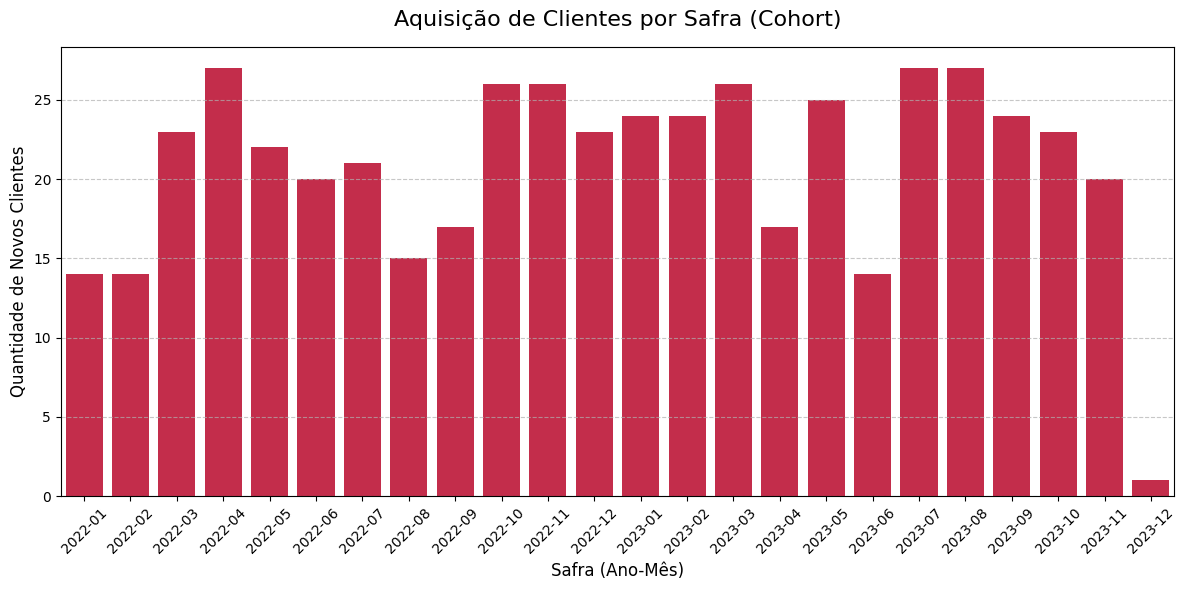

In [19]:
plt.figure(figsize=(12, 6))

cohort_labels = df_customers['cohort_cadastro'].sort_values()

sns.countplot(x=cohort_labels, color="crimson")
plt.title('Aquisição de Clientes por Safra (Cohort)', fontsize=16, pad=15)
plt.xlabel('Safra (Ano-Mês)', fontsize=12)
plt.ylabel('Quantidade de Novos Clientes', fontsize=12)
# Rotacionar os rótulos do eixo X em 45 graus para não ficarem sobrepostos
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Tabela Merchantes

In [20]:
df_merchants = data_excel["merchants"]
df_merchants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   merchant_id                  50 non-null     int64         
 1   nome_restaurante             50 non-null     object        
 2   categoria                    50 non-null     object        
 3   data_ativacao                50 non-null     datetime64[ns]
 4   status                       50 non-null     object        
 5   tempo_medio_preparo_minutos  50 non-null     int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 2.5+ KB


A coluna `merchant_id` está como tipo `int64`, o que pode fazer com que alguns programas tentar somas os valores dessa coluna, o que não deve ser feito. Por essa razão, converteremos essa coluna para o tipo string.

In [21]:
df_merchants["merchant_id"] = df_merchants["merchant_id"].astype(str).str.replace(r'\D', '', regex=True)
df_merchants["merchant_id"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 50 entries, 0 to 49
Series name: merchant_id
Non-Null Count  Dtype 
--------------  ----- 
50 non-null     object
dtypes: object(1)
memory usage: 528.0+ bytes


In [22]:
df_merchants.head(5)

,merchant_id,nome_restaurante,categoria,data_ativacao,status,tempo_medio_preparo_minutos
0,1,Restaurante_1,Pizza,2021-07-09,Ativo,300
1,2,Restaurante_2,Pizza,2021-04-06,Ativo,-10
2,3,Restaurante_3,Brasileira,2021-08-17,Desativado,36
3,4,Restaurante_4,Lanches,2021-01-23,Pausado,45
4,5,Restaurante_5,Lanches,2021-05-15,Ativo,27


Não há valores nulos nessa tabela. De cara é possível ver um valor negativo na coluna tempo_medio_preparo_minutos, o que é irreal e precisa ser tratado.

count     50.000000
mean      31.720000
std       40.164986
min      -10.000000
25%       19.250000
50%       27.000000
75%       33.000000
max      300.000000
Name: tempo_medio_preparo_minutos, dtype: float64


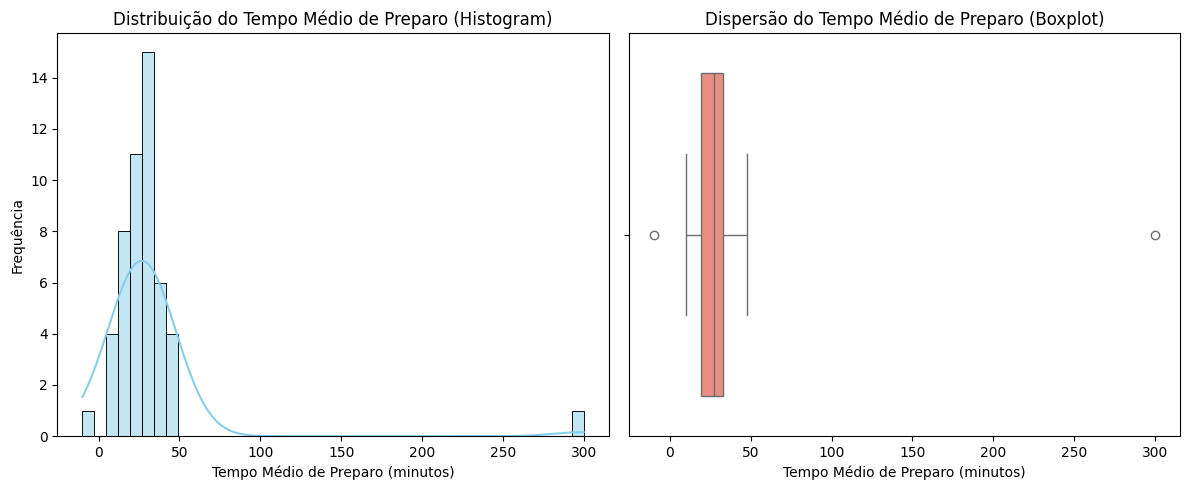

In [23]:
print(df_merchants["tempo_medio_preparo_minutos"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df_merchants, x="tempo_medio_preparo_minutos", kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribuição do Tempo Médio de Preparo (Histogram)")
axes[0].set_xlabel("Tempo Médio de Preparo (minutos)")
axes[0].set_ylabel("Frequência")

sns.boxplot(data=df_merchants, x="tempo_medio_preparo_minutos", ax=axes[1], color="salmon")
axes[1].set_title("Dispersão do Tempo Médio de Preparo (Boxplot)")
axes[1].set_xlabel("Tempo Médio de Preparo (minutos)")

plt.tight_layout()
plt.show()

Da análise do describe() e dos gráficos verifica-se a existência de 2 outliers (-10 e 300).  Excluir as linhas quebraria a integridade relacional com as outras tabelas (pedidos ficariam sem restaurante associado) e não é interessante tornar esses valores como nulo. Levando em consideração as categorias dos restaurantes desses dois outliers, utilizaremos a mediana para substituir os outliers.

In [24]:
outlier_condition = (df_merchants['tempo_medio_preparo_minutos'] < 0) | (df_merchants['tempo_medio_preparo_minutos'] > 120)
df_merchants.loc[outlier_condition, 'tempo_medio_preparo_minutos'] = np.nan
time_by_category = df_merchants.groupby('categoria')['tempo_medio_preparo_minutos'].transform('median')
df_merchants['tempo_medio_preparo_minutos'] = df_merchants['tempo_medio_preparo_minutos'].fillna(time_by_category)

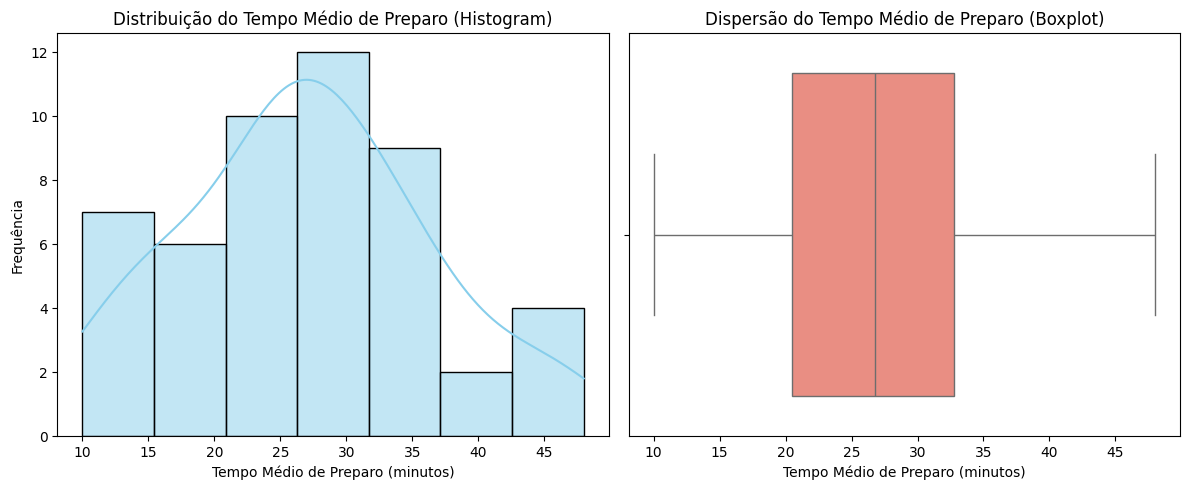

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df_merchants, x="tempo_medio_preparo_minutos", kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribuição do Tempo Médio de Preparo (Histogram)")
axes[0].set_xlabel("Tempo Médio de Preparo (minutos)")
axes[0].set_ylabel("Frequência")

sns.boxplot(data=df_merchants, x="tempo_medio_preparo_minutos", ax=axes[1], color="salmon")
axes[1].set_title("Dispersão do Tempo Médio de Preparo (Boxplot)")
axes[1].set_xlabel("Tempo Médio de Preparo (minutos)")

plt.tight_layout()
plt.show()

### Tabela Riders

In [26]:
df_riders = data_excel["riders"]
df_riders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   rider_id       100 non-null    int64         
 1   tipo_veiculo   94 non-null     object        
 2   data_cadastro  100 non-null    datetime64[ns]
 3   modalidade     100 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 3.2+ KB


In [27]:
df_riders.head(10)

,rider_id,tipo_veiculo,data_cadastro,modalidade
0,1,Moto,2023-04-08,OL
1,2,Moto,2022-10-23,Nuvem
2,3,Moto,2022-10-31,OL
3,4,Moto,2023-05-17,Nuvem
4,5,Carro,2022-07-26,OL
5,6,Moto,2023-02-02,OL
6,7,Moto,2022-07-03,OL
7,8,Bicicleta,2022-11-20,Nuvem
8,9,NaN,2022-10-20,Nuvem
9,10,Carro,2023-04-24,Nuvem


In [ ]:
df_riders['pendencia_cadastro_veiculo'] = df_riders['tipo_veiculo'].isna()

df_riders['tipo_veiculo'] = df_riders['tipo_veiculo'].fillna('Não Informado')

df_riders['rider_id'] = df_riders['rider_id'].astype(str).str.replace(r'\D', '', regex=True)

Há valores nulos na coluna `tipo_veiculo`, o que pode atrapalhar a operação. Sem essa informação, o algoritmo de dispatch não tem como saber qual pedido enviar para aquele entregador. Dito isto, se fez necessário criar a coluna `pendencia_cadastro_veiculo` para que o entregador atualize a informação. Assim, a equipe de operações pode enviar um push no aplicativo do entregador pedindo: "Complete seu cadastro para começar a receber corridas".

Além disso, substituímos os valores nulos por `Não Informado` para que não haja erros em dashboards ou em banco de dados.

Por fim, assim como na tabela `merchants`, trocamos o tipo da coluna `rider_id` para `string`, a fim de evitar que sejam feitos cálculos matemáticos com esses valores.

### Tabela Orders

In [28]:
df_orders = data_excel["orders"]
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   order_id              2000 non-null   int64         
 1   customer_id           2000 non-null   int64         
 2   merchant_id           2000 non-null   int64         
 3   rider_id              1892 non-null   float64       
 4   order_timestamp       2000 non-null   datetime64[ns]
 5   delivery_timestamp    1705 non-null   datetime64[ns]
 6   status_pedido         2000 non-null   object        
 7   valor_produtos        2000 non-null   float64       
 8   taxa_entrega          2000 non-null   float64       
 9   valor_desconto_cupom  2000 non-null   int64         
 10  valor_total_pago      2000 non-null   float64       
 11  metodo_pagamento      2000 non-null   object        
dtypes: datetime64[ns](2), float64(4), int64(4), object(2)
memory usage: 187.6+ K

### Tabela Reviews

In [29]:
df_reviews = data_excel["reviews"]
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   review_id   800 non-null    int64 
 1   order_id    800 non-null    int64 
 2   nota        800 non-null    int64 
 3   comentario  479 non-null    object
dtypes: int64(3), object(1)
memory usage: 25.1+ KB
